In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

**Сценарий:** Представьте, что вы работаете в розничной компании, которая недавно запустила программу лояльности. Компания хочет оценить влияние программы на расходы клиентов. Программа лояльности была развернута в выбранных магазинах (экспериментальная группа), в то время как другие магазины продолжили работу без нее (контрольная группа). У нас есть данные о расходах клиентов до и после запуска программы, и мы хотим оценить, привела ли программа к увеличению выручки, контролируя другие факторы, такие как возраст клиентов и средний доход в месте расположения магазина.

#### Задание 1
Для вас подготовлен csv файл под названием DID_test.csv.<br>
В данном датасете есть следющие колонки: 
* Новый_Маркетинг - флаг, обозначающий проходила ли программа лояльности в данном магазине
* После_Обновления - флаг, обозначающий время замера показателей после или до проведения программы лояльности
* Возраст_Посетителей - средний возраст посетитиелей магазина
* Доход_Посетителей - средний годовой доход посетителей магазина в год
* Выручка_Магазина - выручка магазина за месяц в долларах

Вам необходимо, используя библиотке stasmodels, провести линейную регрессию для прогноза Выручки_Магазина

In [2]:
df = pd.read_csv("DID_test.csv")
print(df.head())

   Новый_Маркетинг  После_Обновления  Возраст_Посетителей  Доход_Посетителей  \
0                1                 0                   25       48887.960002   
1                1                 0                   41       37998.682623   
2                1                 1                   56       63264.716683   
3                1                 0                   22       45506.956139   
4                1                 0                   61       44031.026684   

   Выручка_Магазина  
0        283.368654  
1        319.693095  
2        423.218242  
3        298.164762  
4        360.640089  


In [5]:
X_with_constant = sm.add_constant(df[["Новый_Маркетинг", "После_Обновления", "Возраст_Посетителей", "Доход_Посетителей"]])
model = sm.OLS(df["Выручка_Магазина"], X_with_constant).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Выручка_Магазина   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     86.63
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           3.57e-42
Time:                        12:22:59   Log-Likelihood:                -923.84
No. Observations:                 200   AIC:                             1858.
Df Residuals:                     195   BIC:                             1874.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 201.2975    

#### Задание 2
Интерпретируйте полученные результаты

In [ ]:
# везде p_value меньше 1%, все данные статистически значимые
# Новый_Маркетинг        15.1933: магазины с программой лояльности в среднем имеют на 15.2% больше выручки чем без нее 
# После_Обновления       33.9687: Самый большой процент, после обновления выручка в среднем увеличивается на 34%
# Возраст_Посетителей     1.5718: чем взрослее покупатели, там растет покупка на 1.6%
# Доход_Посетителей       0.0008: при увеличении дохода, выручка растет всего на 0,0008%, маленький эффект

#### Задание 3
Добавьте новую колонку под названием *intersection* которая будет перемножением колонок Новый_Маркетинг и После_Обновления<br>
Данная колонка будет служить признаком для Difference-In-Difference анализа<br>
Постройте линейную регрессую с учетом нового признака

In [6]:
df["Intersection"] = df["Новый_Маркетинг"] * df["После_Обновления"]
X_with_constant = sm.add_constant(df[["Новый_Маркетинг", "После_Обновления", "Возраст_Посетителей", "Доход_Посетителей", "Intersection"]])
model = sm.OLS(df["Выручка_Магазина"], X_with_constant).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Выручка_Магазина   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     75.71
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.02e-43
Time:                        12:30:21   Log-Likelihood:                -917.75
No. Observations:                 200   AIC:                             1847.
Df Residuals:                     194   BIC:                             1867.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 211.7953    

#### Задание 4
Интерпретируйте новые результаты

In [ ]:
# Теперь самый высокий результат в Intersection           24.0960
# Программа лояльности увеличивает выручку в среднем на ~24 единицы после внедрения, по сравнению с контрольной группой
# Также После_Обновления       22.0684: после обновления выручка выросла примерно на 22% у всех

#### Задание 5
Нарисуйте график, показывающий динамику изменений средней выручки между экспериментальной и контрольной группами, до и после кампании

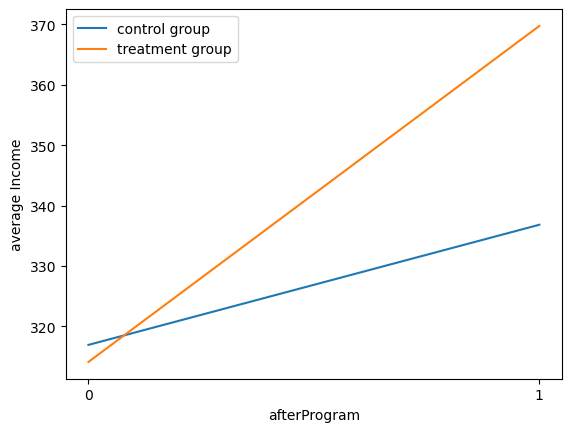

In [7]:
mean00 = df[(df["Новый_Маркетинг"] == 0) & (df["После_Обновления"] == 0)]["Выручка_Магазина"].mean()
mean01 = df[(df["Новый_Маркетинг"] == 0) & (df["После_Обновления"] == 1)]["Выручка_Магазина"].mean()
mean10 = df[(df["Новый_Маркетинг"] == 1) & (df["После_Обновления"] == 0)]["Выручка_Магазина"].mean()
mean11 = df[(df["Новый_Маркетинг"] == 1) & (df["После_Обновления"] == 1)]["Выручка_Магазина"].mean()

plt.plot([mean00, mean01], label = "control group")
plt.plot([mean10, mean11], label = "treatment group")
plt.legend()
plt.xlabel("afterProgram")
plt.ylabel("average Income")
plt.xticks([0,1])
plt.show()